In [1]:
"""
Build Pyrome-specific FlamMap lookups

author: maxwell.cook@colostate.edu
"""

import os, sys

from pathlib import Path
from os.path import join
from fb_tools.weather import (
    load_gridmet_csv, build_flammap_scenario_cache,
    load_flammap_scenario_cache
)

# use the current working directory
projdir = Path.cwd().parents[1] # moves up two, outside code directory
print(f"Project directory set to: {projdir}")

# environ vars
proj_crs = 26913  # NAD83 UTM Zone 13N

Project directory set to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/fire_modeling/FM_PythonWrapper


In [2]:
# --- Load the gridMET climatology by Pyrome
gridmet_fp = Path(join(projdir,"data/tabular/raw/weather/gridmet_clim_CO_pyromes.csv"))
# --- Load and inspect
clim = load_gridmet_csv(gridmet_fp) # parses gridmet columns
print(clim.shape)
print("Pyromes :", sorted(clim["pyrome"].unique()))
print("Years   :", sorted(clim["year"].unique()))
print("Columns :", list(clim.columns))

  [load_gridmet_csv] 30,816 rows, 9 pyromes, years 2010–2025  [legacy flat]
(30816, 18)
Pyromes : [np.int64(42), np.int64(43), np.int64(45), np.int64(46), np.int64(47), np.int64(52), np.int64(53), np.int64(56), np.int64(128)]
Years   : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Columns : ['system:index', 'pyrome', 'date', 'doy', 'erc', 'fm100', 'fm1000', 'pr', 'rmax', 'rmin', 'vpd', 'year', '.geo', 'tmmx_f', 'tmmn_f', 'vpd_pa', 'ws_mph', 'wd_deg']


In [3]:
print("tmmn_f" in clim.columns, "vpd_pa" in clim.columns)

True True


In [4]:
# --- Build wind scenario by pyrome
from fb_tools.weather import wind_percentiles_from_cell_cache

# --- Build the wind dataframe from HRRR cache
wind_pcts = wind_percentiles_from_cell_cache(
    cache_dir=join(projdir,'data/weather/pyrome_wind'),
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.97],  # default
)
wind_pcts['42']

  [wind_percentiles_from_cell_cache] 10 pyromes × 5 percentiles


{'ws_mph': {'p25': 7.8, 'p50': 12.0, 'p75': 16.2, 'p90': 19.9, 'p97': 24.6},
 'wd_deg_mean': None,
 'n_obs': 1127}

In [5]:
# CO pyromes span ~37–41°N; 39.5° used for GSI photoperiod calculation.
# GSI uses tmmn_f (min temp), vpd_pa (from GEE export), and daylength.
# wind_direction=-2 = downhill (worst-case); override with -1 (uphill)
# or an explicit azimuth (0–360) as needed.

CACHE_DIR  = Path(join(projdir,"data/weather/flammap/"))

percentiles = [0.25, 0.50, 0.75, 0.90, 0.97]

scenarios = build_flammap_scenario_cache(
    clim,
    pyrome_col="pyrome",
    percentiles=percentiles,
    out_dir=CACHE_DIR,
    lat_deg=39.5, # adjust as-needed
    wind_direction=-2, # FlamMap downhill default
    wind_percentiles=wind_pcts,
)
scenarios

  [gridmet] Wrote pyrome_42_flammap.json
  [gridmet] Wrote pyrome_43_flammap.json
  [gridmet] Wrote pyrome_45_flammap.json
  [gridmet] Wrote pyrome_46_flammap.json
  [gridmet] Wrote pyrome_47_flammap.json
  [gridmet] Wrote pyrome_52_flammap.json
  [gridmet] Wrote pyrome_53_flammap.json
  [gridmet] Wrote pyrome_56_flammap.json
  [gridmet] Wrote pyrome_128_flammap.json
  [build_flammap_scenario_cache] 9 pyromes × 5 scenarios (±0.025 ERC band, wind=external)


{'42': {'pyrome_id': '42',
  'percentiles': [0.25, 0.5, 0.75, 0.9, 0.97],
  'erc_band': 0.025,
  'wind_direction': -2,
  'wind_speed_source': 'external',
  'scenarios': {'p25': {'FM_1hr': 4.6,
    'FM_10hr': 8.5,
    'FM_100hr': 14.5,
    'FM_100hr_gridmet': 8.9,
    'FM_herb': 94.4,
    'FM_woody': 130.7,
    'WIND_DIRECTION': -2,
    'erc_quantile_band': [0.225, 0.275],
    'erc_center': 59.7,
    'scenario_doy': 236,
    'n_sample_days': 172,
    'WIND_SPEED': 7.8},
   'p50': {'FM_1hr': 3.5,
    'FM_10hr': 6.4,
    'FM_100hr': 9.1,
    'FM_100hr_gridmet': 7.2,
    'FM_herb': 59.3,
    'FM_woody': 82.1,
    'WIND_DIRECTION': -2,
    'erc_quantile_band': [0.475, 0.525],
    'erc_center': 72.0,
    'scenario_doy': 250,
    'n_sample_days': 180,
    'WIND_SPEED': 12.0},
   'p75': {'FM_1hr': 2.9,
    'FM_10hr': 5.3,
    'FM_100hr': 6.1,
    'FM_100hr_gridmet': 5.4,
    'FM_herb': 39.6,
    'FM_woody': 60.0,
    'WIND_DIRECTION': -2,
    'erc_quantile_band': [0.725, 0.775],
    'erc_cente

In [6]:
# --- Look up Pyrome
# --- Load the Pyrome-specific FlamMap inputs
from fb_tools.weather import load_flammap_scenario_cache

# --- Pyrome 46 CO Rockies
fm_params = load_flammap_scenario_cache(46, CACHE_DIR)
fm_params

{'pyrome_id': '46',
 'percentiles': [0.25, 0.5, 0.75, 0.9, 0.97],
 'erc_band': 0.025,
 'wind_direction': -2,
 'wind_speed_source': 'external',
 'scenarios': {'p25': {'FM_1hr': 6.1,
   'FM_10hr': 13.2,
   'FM_100hr': 23.0,
   'FM_100hr_gridmet': 12.1,
   'FM_herb': 149.2,
   'FM_woody': 200.0,
   'WIND_DIRECTION': -2,
   'erc_quantile_band': [0.225, 0.275],
   'erc_center': 38.0,
   'scenario_doy': 229,
   'n_sample_days': 173,
   'WIND_SPEED': 8.1},
  'p50': {'FM_1hr': 4.9,
   'FM_10hr': 9.2,
   'FM_100hr': 16.4,
   'FM_100hr_gridmet': 9.9,
   'FM_herb': 106.8,
   'FM_woody': 147.9,
   'WIND_DIRECTION': -2,
   'erc_quantile_band': [0.475, 0.525],
   'erc_center': 48.0,
   'scenario_doy': 230,
   'n_sample_days': 187,
   'WIND_SPEED': 12.3},
  'p75': {'FM_1hr': 4.1,
   'FM_10hr': 7.7,
   'FM_100hr': 11.7,
   'FM_100hr_gridmet': 8.5,
   'FM_herb': 76.0,
   'FM_woody': 105.3,
   'WIND_DIRECTION': -2,
   'erc_quantile_band': [0.725, 0.775],
   'erc_center': 58.8,
   'scenario_doy': 230,
  

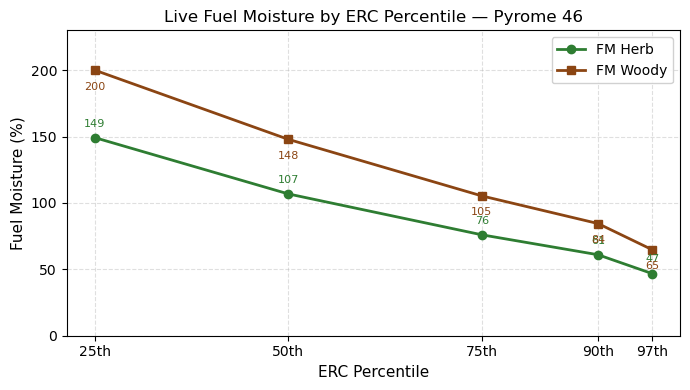

In [7]:
import matplotlib.pyplot as plt

percentile_labels = [f"p{int(p*100)}" for p in fm_params['percentiles']]
fm_herb  = [fm_params['scenarios'][k]['FM_herb']  for k in percentile_labels]
fm_woody = [fm_params['scenarios'][k]['FM_woody'] for k in percentile_labels]
x = fm_params['percentiles']

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x, fm_herb,  marker='o', lw=2, color='#2E7D32', label='FM Herb',  zorder=3)
ax.plot(x, fm_woody, marker='s', lw=2, color='#8B4513', label='FM Woody', zorder=3)

# Annotate values
for xi, yh, yw in zip(x, fm_herb, fm_woody):
    ax.annotate(f'{yh:.0f}',  (xi, yh),  textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8, color='#2E7D32')
    ax.annotate(f'{yw:.0f}', (xi, yw), textcoords='offset points', xytext=(0, -14),
                ha='center', fontsize=8, color='#8B4513')

ax.set_xticks(x)
ax.set_xticklabels([f"{int(p*100)}th" for p in x])
ax.set_xlabel('ERC Percentile', fontsize=11)
ax.set_ylabel('Fuel Moisture (%)', fontsize=11)
ax.set_title(f"Live Fuel Moisture by ERC Percentile — Pyrome {fm_params['pyrome_id']}", fontsize=12)
ax.legend(framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(0, max(fm_woody) * 1.15)

plt.tight_layout()
plt.savefig('fm_by_percentile.png', dpi=150, bbox_inches='tight')
plt.show()